In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [5]:
from utiles_func import unwrap_failure_type, plot_example_maps

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
pd.__version__

'2.3.3'

### Phase 1: Load the data

In [8]:
df = pd.read_pickle("../raw_data/wm811k/LSWMD.pkl")

#### Explore the dataset

In [9]:
df.shape

(811457, 6)

In [10]:
df.columns

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

In [11]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [12]:
df.waferMap[0].shape

(45, 48)

In [13]:
print("Unique values:", sorted(set(df.waferMap[0].ravel())))

Unique values: [np.uint8(0), np.uint8(1), np.uint8(2)]


In [14]:
df.failureType

0              [[none]]
1              [[none]]
2              [[none]]
3              [[none]]
4              [[none]]
              ...      
811452    [[Edge-Ring]]
811453     [[Edge-Loc]]
811454    [[Edge-Ring]]
811455               []
811456               []
Name: failureType, Length: 811457, dtype: object

In [15]:
df['Label'] = df.failureType.apply(unwrap_failure_type)

In [16]:
df.Label.unique()

array(['none', 'Loc', None, 'Edge-Loc', 'Center', 'Edge-Ring', 'Scratch',
       'Random', 'Near-full', 'Donut'], dtype=object)

In [17]:
df.Label = df.Label.replace({'none': 'None'})

In [18]:
df.Label.unique()

array(['None', 'Loc', None, 'Edge-Loc', 'Center', 'Edge-Ring', 'Scratch',
       'Random', 'Near-full', 'Donut'], dtype=object)

In [19]:
df.Label.value_counts(dropna=False)

Label
None         638507
None         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

In [20]:
shape_set = set()
shape_distribution = {}
for i in range(len(df.waferMap)):
    if df.waferMap[i].shape not in shape_set:
        shape_distribution[df.waferMap[i].shape] = 1
    else:
        shape_distribution[df.waferMap[i].shape] += 1
    shape_set.add(df.waferMap[i].shape)

In [21]:
df_shape_distribution = pd.DataFrame(list(shape_distribution.items()), columns=['Shape', 'Count'])

In [22]:
df_shape_distribution

,Shape,Count
0,"(45, 48)",621
1,"(53, 58)",1212
2,"(26, 26)",30078
3,"(70, 58)",24
4,"(107, 183)",24
...,...,...
627,"(15, 3)",1
628,"(21, 17)",1
629,"(27, 15)",1
630,"(18, 44)",1


In [23]:
class_names = list(df.Label.unique())
class_names

['None',
 'Loc',
 None,
 'Edge-Loc',
 'Center',
 'Edge-Ring',
 'Scratch',
 'Random',
 'Near-full',
 'Donut']

Label: None | Number of examples: 4


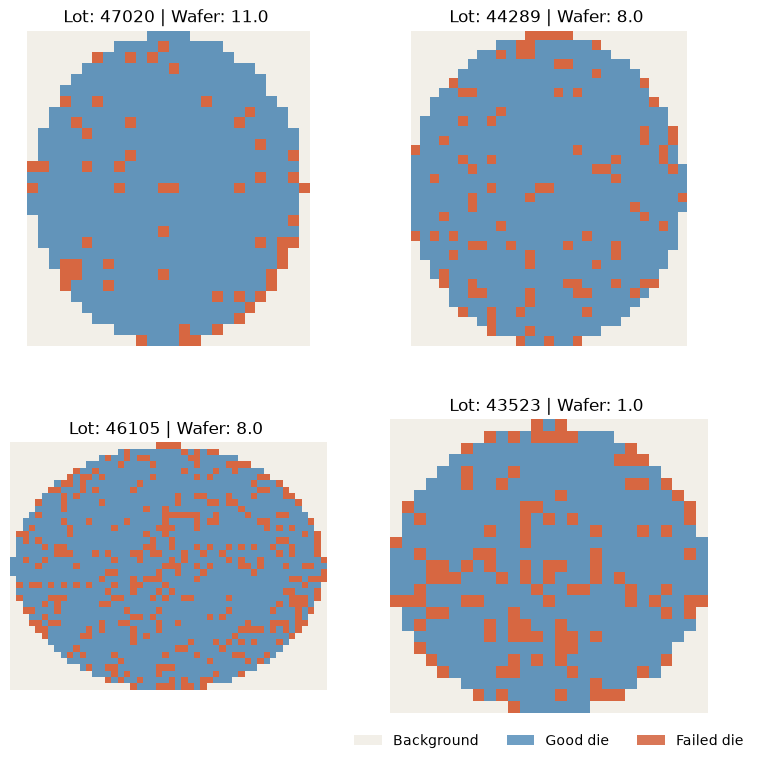

Label: Loc | Number of examples: 4


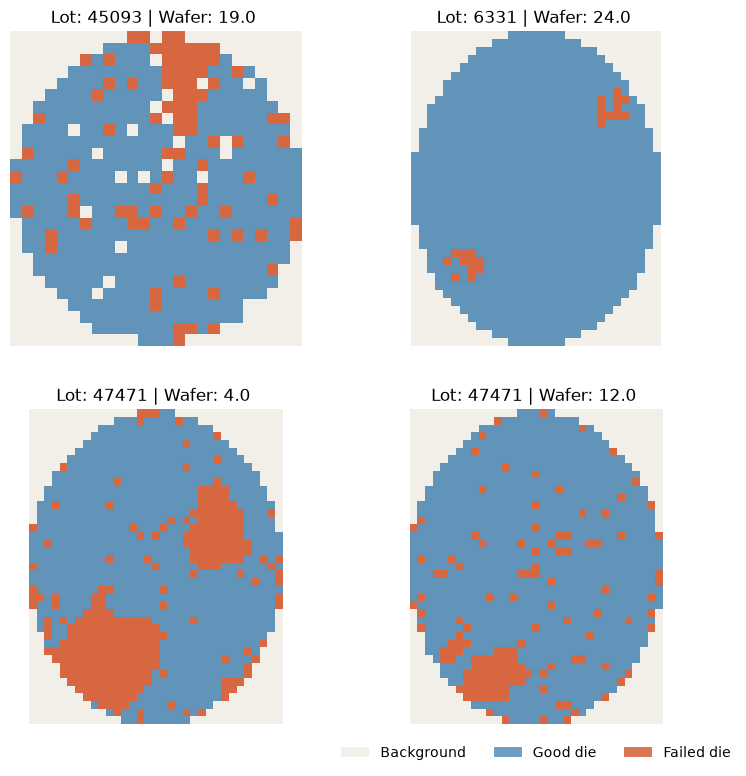

Label: Edge-Loc | Number of examples: 4


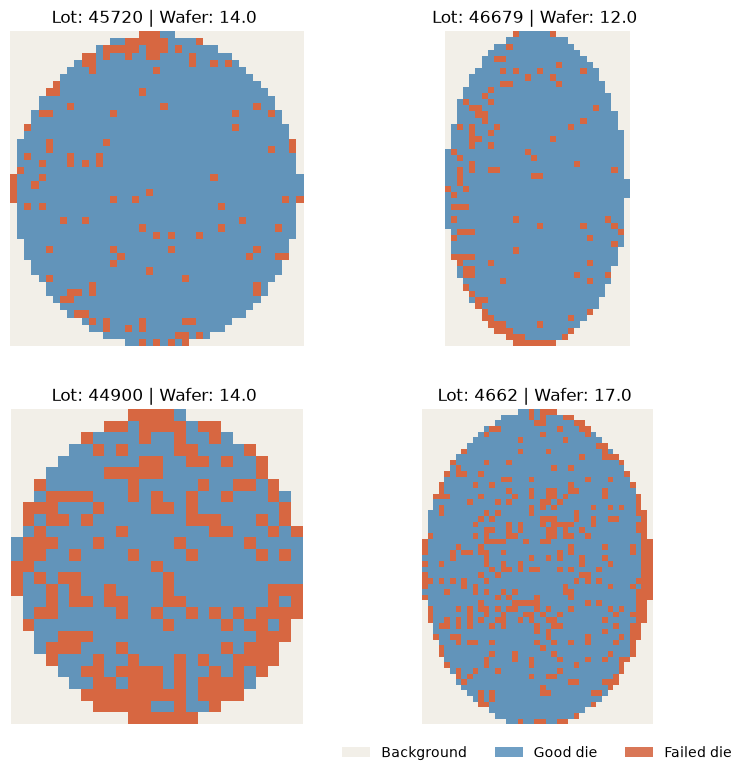

Label: Center | Number of examples: 4


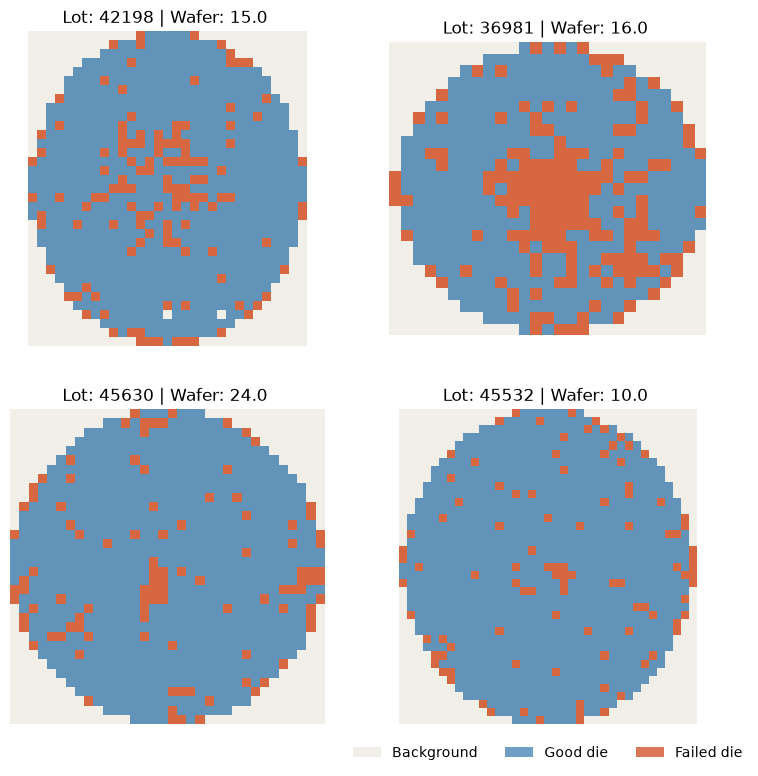

Label: Edge-Ring | Number of examples: 4


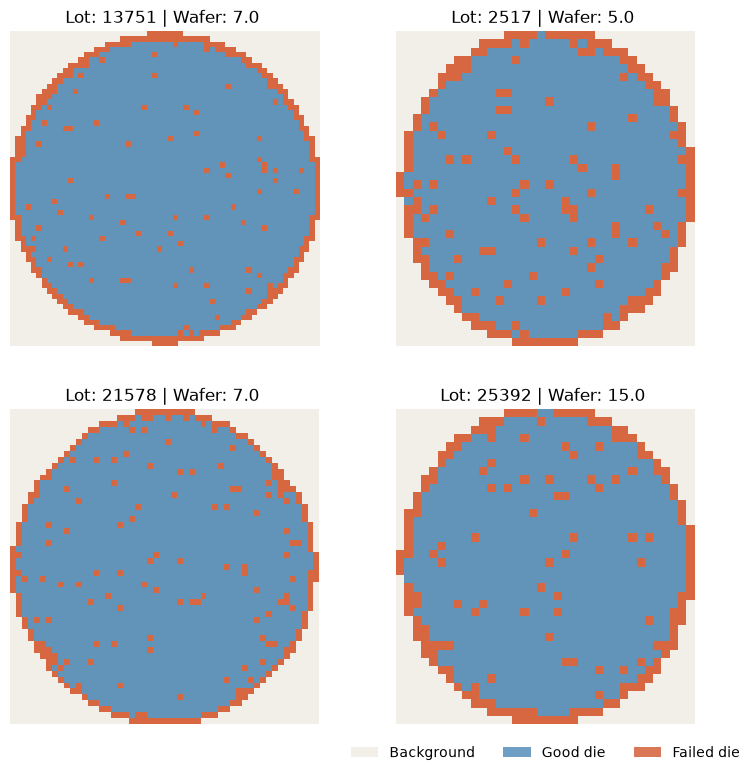

Label: Scratch | Number of examples: 4


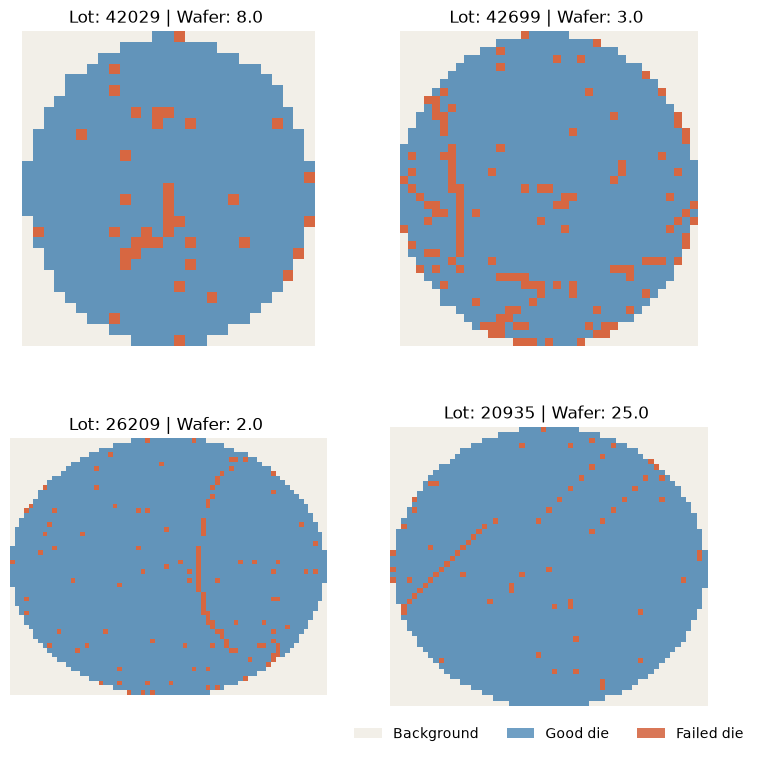

Label: Random | Number of examples: 4


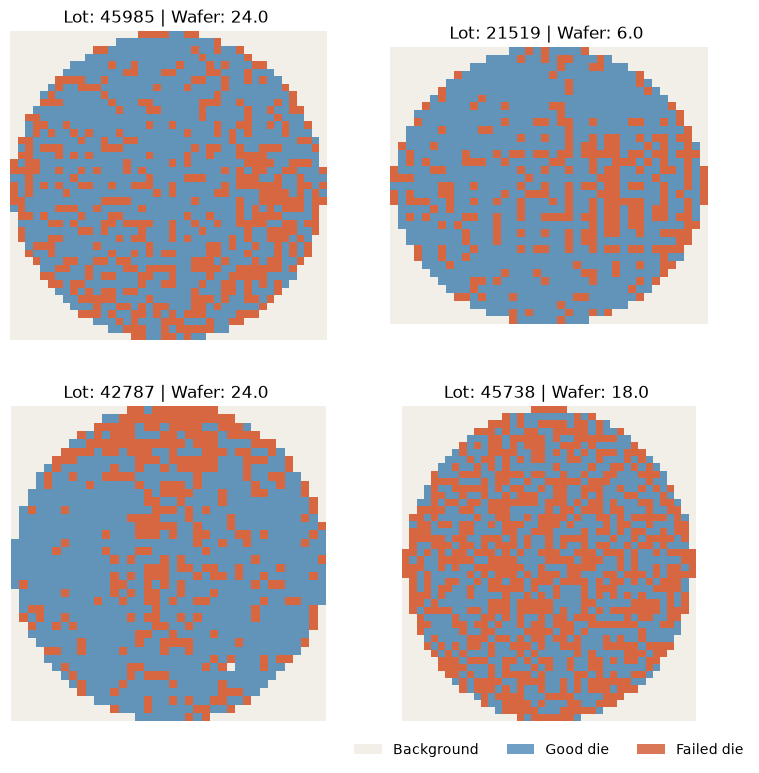

Label: Near-full | Number of examples: 4


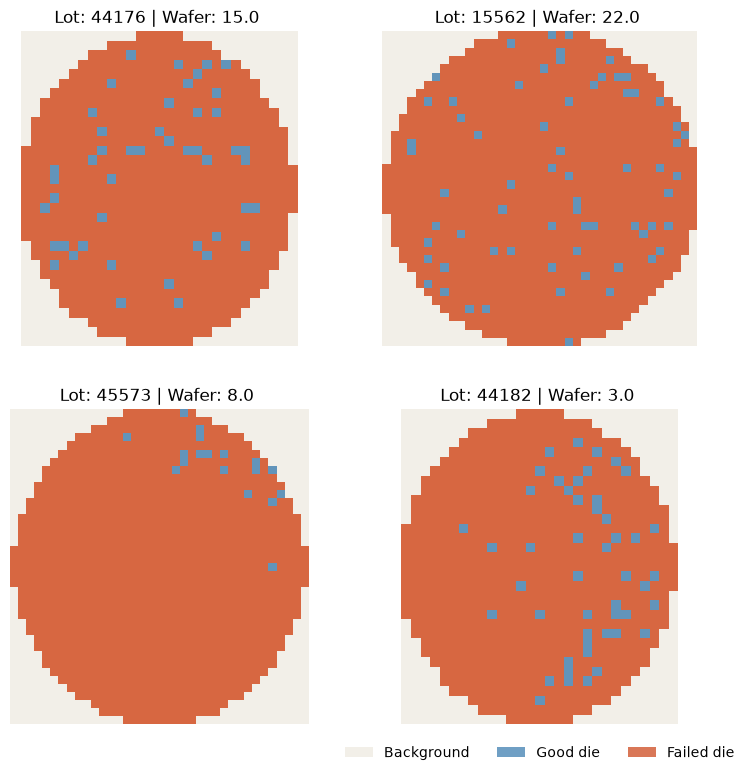

Label: Donut | Number of examples: 4


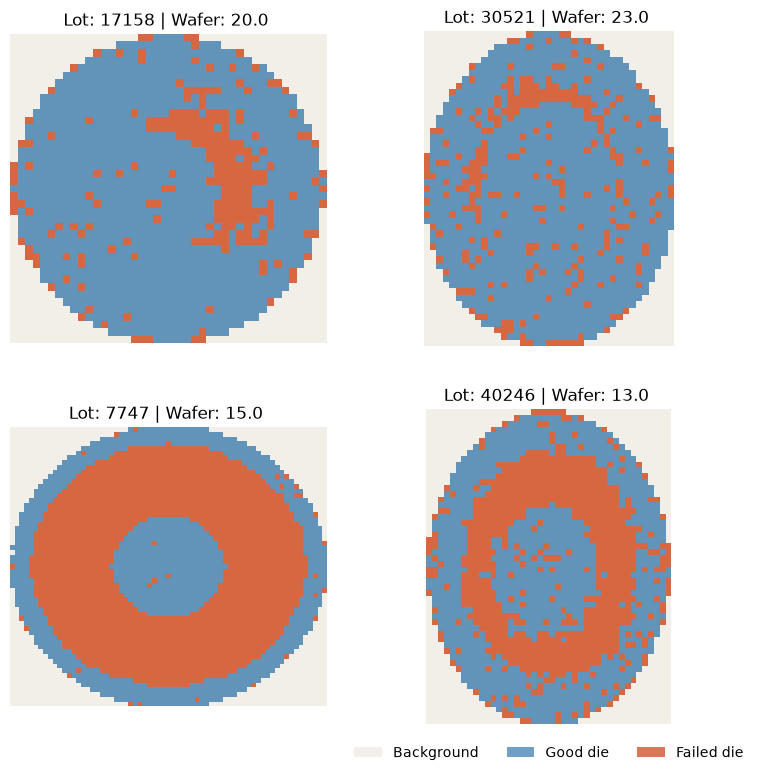

In [24]:
for label in class_names:
    if label is None:
        continue  # Skip the 'None' label
    example_maps = (
        df.loc[df["Label"].eq(label)]
        .sample(n=4, random_state=42)
    )
    wafer_maps = example_maps["waferMap"]
    
    print(f"Label: {label} | Number of examples: {len(example_maps)}")
    
    plot_example_maps(example_maps, wafer_maps)